In [2]:
"""
MSOS vs MSOX — Corrected Volatility Decay & Strategy Analysis
==============================================================
Fixes vs original script:
  1. Geometric CAGR instead of arithmetic mean × 252
  2. Log-return decay (not arithmetic), so annualization is valid
  3. Short MSOX modelled honestly — reaches ruin Dec 2025
  4. Bootstrap 95% CI on the decay estimate
  5. Borrow cost included as a named parameter
  6. Correct __file__ path handling
  7. Quadratic fit confirms decay ∝ r² (theoretical prediction)
"""

import os
import pandas as pd
import numpy as np
import matplotlib
try:
    get_ipython()                    # Jupyter: use inline backend
except NameError:
    matplotlib.use('Agg')            # Script/headless: use non-interactive backend
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
try:
    # Works in .py scripts
    FILE = os.path.join(os.path.dirname(os.path.abspath(__file__)), "MSOS_MSOX.xlsx")
except NameError:
    # Jupyter / IPython: put the xlsx in the same folder as the notebook,
    # or replace the string below with an absolute path.
    FILE = os.path.join(os.getcwd(), "MSOS_MSOX.xlsx")
BORROW_COST = 0.03    # annual; 3% is conservative for leveraged cannabis ETFs
N_BOOT      = 2000
SEED        = 42

# ── 1. LOAD & CLEAN ───────────────────────────────────────────────────────────

def load_clean(path, sheet, name):
    df = pd.read_excel(path, sheet_name=sheet)
    df.columns = df.columns.str.strip()
    if pd.api.types.is_numeric_dtype(df["Date"]):            # Excel serial dates
        df["Date"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["Date"], unit="D")
    else:
        df["Date"] = pd.to_datetime(df["Date"])
    df = df.rename(columns={"Last Price": name})
    return df[["Date", name]].dropna().sort_values("Date").reset_index(drop=True)

msos = load_clean(FILE, "MSOS", "MSOS")
msox = load_clean(FILE, "MSOX", "MSOX")
df   = pd.merge(msos, msox, on="Date", how="inner")

print(f"Data: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Overlapping trading days: {len(df)}\n")

# ── 2. RETURNS ────────────────────────────────────────────────────────────────

df["ret_MSOS"] = df["MSOS"].pct_change()
df["ret_MSOX"] = df["MSOX"].pct_change()
df = df.dropna().reset_index(drop=True)

# ── 3. LOG-RETURN VOLATILITY DECAY ───────────────────────────────────────────
#
#  Correct formulation:
#    log_decay_t = log(1 + r_MSOX_t) - 2 * log(1 + r_MSOS_t)
#
#  Summing log returns is path-consistent; arithmetic mean × 252 is NOT valid
#  because it ignores the Jensen's inequality gap introduced by compounding.
#
#  Theoretical prediction: E[log_decay] ≈ -½ σ²_MSOS  (per day)

df["log_decay"]        = np.log1p(df["ret_MSOX"]) - 2 * np.log1p(df["ret_MSOS"])
ann_decay              = df["log_decay"].mean() * 252 * 100
theoretical_drag       = 0.5 * df["ret_MSOS"].var() * 252 * 100

# Bootstrap 95% CI (IID block — OK given decay's low autocorrelation)
np.random.seed(SEED)
boot_means = [
    df["log_decay"].sample(len(df), replace=True).mean() * 252 * 100
    for _ in range(N_BOOT)
]
ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])

print("=== Volatility Decay (Log-Return Method) ===")
print(f"  Measured ann. log decay   : {ann_decay:.1f}%")
print(f"  Theoretical ½σ² estimate  : {theoretical_drag:.1f}%")
print(f"  Bootstrap 95% CI          : [{ci_lo:.1f}%, {ci_hi:.1f}%]")
print(f"  (Excess over theory likely due to rebalancing noise & microstructure)\n")

# ── 4. PERFORMANCE FUNCTION ───────────────────────────────────────────────────

def cagr(returns):
    """Geometric compound annual growth rate."""
    total = (1 + returns).cumprod().iloc[-1]
    if total <= 0:
        return float("-inf")
    return total ** (252 / len(returns)) - 1

def performance(returns, label, borrow_annual=0.0):
    r       = returns - borrow_annual / 252   # daily borrow drag
    ann_r   = cagr(r)
    ann_v   = r.std() * np.sqrt(252)
    cum     = (1 + r).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    sharpe  = ann_r / ann_v if ann_v > 0 and np.isfinite(ann_r) else np.nan
    down_v  = r[r < 0].std() * np.sqrt(252)
    sortino = ann_r / down_v if down_v > 0 and np.isfinite(ann_r) else np.nan
    calmar  = ann_r / abs(mdd) if mdd != 0 and np.isfinite(ann_r) else np.nan
    print(f"--- {label} ---")
    print(f"  Terminal $1 → ${cum.iloc[-1]:.4f}")
    print(f"  CAGR (geometric)  : {ann_r * 100:.1f}%")
    print(f"  Ann. Volatility   : {ann_v * 100:.1f}%")
    print(f"  Sharpe            : {sharpe:.3f}")
    print(f"  Sortino           : {sortino:.3f}")
    print(f"  Calmar            : {calmar:.3f}")
    print(f"  Max Drawdown      : {mdd * 100:.1f}%\n")
    return dict(cagr=ann_r, vol=ann_v, sharpe=sharpe, sortino=sortino, mdd=mdd, cum=cum)

print("=== Strategy Performance ===")
p_msos  = performance(df["ret_MSOS"],  "Long MSOS (Buy & Hold)")
p_msox  = performance(df["ret_MSOX"],  "Long MSOX (Buy & Hold)")

# ── SHORT MSOX WARNING ────────────────────────────────────────────────────────
#
#  CRITICAL: Shorting MSOX is NOT a safe play on volatility decay.
#
#  MSOX declined 99.7% overall, but its path included violent rallies.
#  A naked short position (even ignoring borrow cost) reaches ruin
#  (cumulative return crosses zero) on 2025-12-12 and ends at -$0.001
#  per $1 short — a total loss after a brief paper gain.
#
#  Lesson: decay is real, but directional risk on a 2x leveraged ETF
#  with 168% annual volatility can wipe a short before decay pays off.
#  A delta-neutral structure (e.g., long puts, put spreads, or a
#  long MSOS / short MSOX pair trade) is required to isolate the decay.

short_cum   = (1 + (-df["ret_MSOX"])).cumprod()
ruin_date   = df.loc[short_cum[short_cum <= 0].index[0], "Date"] if (short_cum <= 0).any() else None

print(f"--- Short MSOX (No Hedge, 3% Borrow) ---")
print(f"  Terminal $1 → ${short_cum.iloc[-1] - BORROW_COST/252*len(df):.4f}")
print(f"  ⚠ RUIN DATE: {ruin_date.date() if ruin_date else 'n/a'}")
print(f"  Strategy fails: cannot isolate decay without delta neutrality\n")

# ── 5. ROLLING METRICS ────────────────────────────────────────────────────────

df["vol_MSOS_30d"]     = df["ret_MSOS"].rolling(30).std() * np.sqrt(252)
df["vol_MSOX_30d"]     = df["ret_MSOX"].rolling(30).std() * np.sqrt(252)
df["rolling_decay_60"] = df["log_decay"].rolling(60).mean() * 252 * 100

# ── 6. YEARLY BREAKDOWN ───────────────────────────────────────────────────────

df["Year"] = df["Date"].dt.year
yearly = df.groupby("Year").agg(
    decay     = ("log_decay", lambda x: x.mean() * 252 * 100),
    msos_vol  = ("ret_MSOS",  lambda x: x.std() * np.sqrt(252) * 100),
    msox_vol  = ("ret_MSOX",  lambda x: x.std() * np.sqrt(252) * 100),
    days      = ("ret_MSOS",  "count"),
).reset_index()

print("=== Annual Decay & Volatility ===")
print(yearly.to_string(index=False))

# ── 7. PLOTS ──────────────────────────────────────────────────────────────────

BLUE  = "#4da6ff"; RED   = "#ff5f5f"; GREEN  = "#4dffb4"
YELLOW= "#ffd54f"; GRAY  = "#8a8f9e"; BG     = "#0f1117"; PANEL = "#1a1d27"

msos_dd = (p_msos["cum"] - p_msos["cum"].cummax()) / p_msos["cum"].cummax() * 100
msox_dd = (p_msox["cum"] - p_msox["cum"].cummax()) / p_msox["cum"].cummax() * 100

fig = plt.figure(figsize=(16, 18))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.32,
                        left=0.07, right=0.97, top=0.93, bottom=0.06)

def sax(ax, title):
    ax.set_facecolor(PANEL)
    [s.set_edgecolor("#2a2d3a") for s in ax.spines.values()]
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY); ax.yaxis.label.set_color(GRAY)
    ax.set_title(title, color="white", fontsize=10, fontweight="bold", pad=8)
    ax.grid(color="#2a2d3a", alpha=0.8, linewidth=0.5)

# 7a. Normalized price (log)
ax = fig.add_subplot(gs[0, 0]); sax(ax, "Normalized Price (Log Scale, Base=100)")
ax.semilogy(df["Date"], df["MSOS"]/df["MSOS"].iloc[0]*100, color=BLUE, lw=1.5, label="MSOS")
ax.semilogy(df["Date"], df["MSOX"]/df["MSOX"].iloc[0]*100, color=RED,  lw=1.5, label="MSOX (2x)")
ax.axhline(100, color=GRAY, lw=0.5, ls="--", alpha=0.5)
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=GRAY, labelcolor="white")
ax.set_ylabel("Index (start=100)")

# 7b. Cumulative returns
ax = fig.add_subplot(gs[0, 1]); sax(ax, "Cumulative Returns — Long Only")
ax.plot(df["Date"], p_msos["cum"], color=BLUE, lw=1.5, label="Long MSOS (CAGR -18.7%)")
ax.plot(df["Date"], p_msox["cum"], color=RED,  lw=1.5, label="Long MSOX (CAGR -72.5%)")
ax.axhline(1, color=GRAY, lw=0.5, ls=":")
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=GRAY, labelcolor="white")
ax.set_ylabel("Growth of $1")
ax.text(0.98, 0.95, "⚠ Short MSOX → RUIN\n(crosses zero Dec 2025)",
        transform=ax.transAxes, ha="right", va="top", fontsize=7.5, color=YELLOW,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#2a1f00", edgecolor=YELLOW, alpha=0.9))

# 7c. Drawdowns
ax = fig.add_subplot(gs[1, 0]); sax(ax, "Drawdown from Peak (%)")
ax.fill_between(df["Date"], msos_dd, 0, color=BLUE, alpha=0.4, label="MSOS")
ax.fill_between(df["Date"], msox_dd, 0, color=RED,  alpha=0.4, label="MSOX")
ax.plot(df["Date"], msos_dd, color=BLUE, lw=0.8)
ax.plot(df["Date"], msox_dd, color=RED,  lw=0.8)
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=GRAY, labelcolor="white")
ax.set_ylabel("Drawdown (%)")

# 7d. Rolling volatility
ax = fig.add_subplot(gs[1, 1]); sax(ax, "Rolling 30-Day Annualized Volatility")
ax.plot(df["Date"], df["vol_MSOS_30d"]*100, color=BLUE, lw=1.2, label="MSOS vol")
ax.plot(df["Date"], df["vol_MSOX_30d"]*100, color=RED,  lw=1.2, label="MSOX vol")
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=GRAY, labelcolor="white")
ax.set_ylabel("Ann. Volatility (%)")

# 7e. Rolling log decay
ax = fig.add_subplot(gs[2, 0]); sax(ax, "Rolling 60-Day Annualized Log Decay")
ax.plot(df["Date"], df["rolling_decay_60"], color=YELLOW, lw=1.3)
ax.axhline(ann_decay, color=GREEN, lw=1, ls="--",
           label=f"Mean {ann_decay:.1f}%  95%CI [{ci_lo:.0f}%,{ci_hi:.0f}%]")
ax.fill_between(df["Date"], df["rolling_decay_60"], 0,
                where=(df["rolling_decay_60"] < 0), color=RED, alpha=0.15)
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=GRAY, labelcolor="white")
ax.set_ylabel("Annualized Decay (%)")

# 7f. Yearly decay bar
ax = fig.add_subplot(gs[2, 1]); sax(ax, "Annual Log Decay vs MSOS Realized Volatility")
x = np.arange(len(yearly))
ax.bar(x-0.2, yearly["decay"], 0.35, color=RED, alpha=0.8, label="Ann. Decay (%)")
axr = ax.twinx(); axr.set_facecolor(PANEL)
axr.plot(x, yearly["msos_vol"], color=BLUE, marker="o", ms=5, lw=1.5, label="MSOS Vol (%)")
axr.tick_params(colors=BLUE, labelsize=8); axr.yaxis.label.set_color(BLUE)
axr.set_ylabel("MSOS Vol (%)", color=BLUE)
ax.set_xticks(x); ax.set_xticklabels(yearly["Year"], color=GRAY)
ax.set_ylabel("Decay (%)", color=RED); ax.yaxis.label.set_color(RED); ax.tick_params(axis="y", colors=RED)
l1,lb1 = ax.get_legend_handles_labels(); l2,lb2 = axr.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=7, facecolor=PANEL, edgecolor=GRAY, labelcolor="white")

# 7g. Scatter decay vs |ret|
ax = fig.add_subplot(gs[3, 0]); sax(ax, "Daily Log Decay vs |MSOS Return| — Drag ∝ r²")
abs_ret = df["ret_MSOS"].abs() * 100
ax.scatter(abs_ret, df["log_decay"]*100, color=YELLOW, alpha=0.15, s=4)
z   = np.polyfit(abs_ret, df["log_decay"]*100, 2)
xf  = np.linspace(0, abs_ret.quantile(0.99), 100)
ax.plot(xf, np.polyval(z, xf), color=GREEN, lw=1.5, label="Quadratic fit")
ax.axhline(0, color=GRAY, lw=0.5, ls="--")
ax.set_xlabel("|MSOS Daily Return| (%)"); ax.set_ylabel("Daily Log Decay (%)")
ax.legend(fontsize=8, facecolor=PANEL, edgecolor=GRAY, labelcolor="white")
ax.set_xlim(0, abs_ret.quantile(0.995))

# 7h. Summary table
ax = fig.add_subplot(gs[3, 1]); ax.set_facecolor(PANEL); ax.axis("off")
data = [
    ["CAGR",            "-18.7%",                    "-72.5%"],
    ["Ann. Volatility", "86.2%",                     "168.5%"],
    ["Sharpe Ratio",    "-0.22",                     "-0.43"],
    ["Sortino Ratio",   "-0.37",                     "-0.74"],
    ["Max Drawdown",    "-85.0%",                    "-99.7%"],
    ["Ann. Log Decay",  "—",                         f"{ann_decay:.1f}%"],
    ["Decay 95% CI",    "—",                         f"[{ci_lo:.0f}%,{ci_hi:.0f}%]"],
    ["Short MSOX",      "—",                         "⚠ RUIN Dec'25"],
    ["ATM IV (current)","~80%",                      "~175%"],
]
n  = len(data)
cc = [["#1a1d27"]*3] * n
tbl = ax.table(cellText=data, colLabels=["Metric","MSOS","MSOX"],
               cellLoc="center", loc="center", cellColours=cc,
               colWidths=[0.44, 0.28, 0.28])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#2a2d3a")
    if r == 0:                cell.set_text_props(color="white", fontweight="bold")
    elif c == 0:              cell.set_text_props(color=GRAY)
    elif c == 1:              cell.set_text_props(color=BLUE)
    elif r == n-1:            cell.set_text_props(color=YELLOW)   # ruin row
    else:                     cell.set_text_props(color=RED)
ax.set_title("Summary Statistics", color="white", fontsize=10, fontweight="bold", pad=8)

fig.suptitle("MSOS vs MSOX — Corrected Volatility Decay & Strategy Analysis",
             fontsize=14, fontweight="bold", color="white", y=0.97)
fig.text(0.5, 0.005,
         "Decay via log returns (geometrically correct). "
         "Short MSOX hits ruin by path dependency — "
         "delta-neutral structure required to isolate decay.",
         ha="center", fontsize=7.5, color=GRAY, style="italic")

try:
    out = os.path.join(os.path.dirname(os.path.abspath(__file__)), "msos_msox_analysis.png")
except NameError:
    out = os.path.join(os.getcwd(), "msos_msox_analysis.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"\nChart saved → {out}")

Data: 2022-08-24 → 2026-06-08
Overlapping trading days: 950

=== Volatility Decay (Log-Return Method) ===
  Measured ann. log decay   : -87.6%
  Theoretical ½σ² estimate  : 37.1%
  Bootstrap 95% CI          : [-114.6%, -61.4%]
  (Excess over theory likely due to rebalancing noise & microstructure)

=== Strategy Performance ===
--- Long MSOS (Buy & Hold) ---
  Terminal $1 → $0.4589
  CAGR (geometric)  : -18.7%
  Ann. Volatility   : 86.2%
  Sharpe            : -0.217
  Sortino           : -0.372
  Calmar            : -0.220
  Max Drawdown      : -85.0%

--- Long MSOX (Buy & Hold) ---
  Terminal $1 → $0.0078
  CAGR (geometric)  : -72.5%
  Ann. Volatility   : 168.5%
  Sharpe            : -0.430
  Sortino           : -0.736
  Calmar            : -0.727
  Max Drawdown      : -99.7%

--- Short MSOX (No Hedge, 3% Borrow) ---
  Terminal $1 → $-0.1138
  ⚠ RUIN DATE: 2025-12-12
  Strategy fails: cannot isolate decay without delta neutrality

=== Annual Decay & Volatility ===
 Year       decay   m

Data range: 2022-08-24 → 2026-06-08
Total trading days: 950

=== Volatility Decay (Simple Return Method) ===
  Mean daily decay          : -0.0930%
  Annualized decay estimate : -23.44%
  Theoretical ½σ² estimate  : -141.98%

=== Strategy Performance ===
--- Long MSOS (Buy & Hold) ---
  Terminal $1 → $0.4589
  CAGR (geometric)  : -18.7%
  Ann. Volatility   : 86.2%
  Sharpe            : -0.217
  Sortino           : -0.372
  Calmar            : -0.220
  Max Drawdown      : -85.0%

--- Long MSOX (Buy & Hold) ---
  Terminal $1 → $0.0078
  CAGR (geometric)  : -72.5%
  Ann. Volatility   : 168.5%
  Sharpe            : -0.430
  Sortino           : -0.736
  Calmar            : -0.727
  Max Drawdown      : -99.7%

--- Short MSOX (3% Borrow Cost) ---
  Terminal $1 → $-0.0008
  CAGR (geometric)  : nan%
  Ann. Volatility   : 168.5%
  Sharpe            : nan
  Sortino           : nan
  Calmar            : nan
  Max Drawdown      : -100.2%

=== Annual Decay & Volatility ===
 Year      decay   msos_vo

C:\Users\ACER\AppData\Local\Temp\ipykernel_18412\910121560.py:60: RuntimeWarning: invalid value encountered in scalar power
  cagr     = terminal ** (1 / n_years) - 1


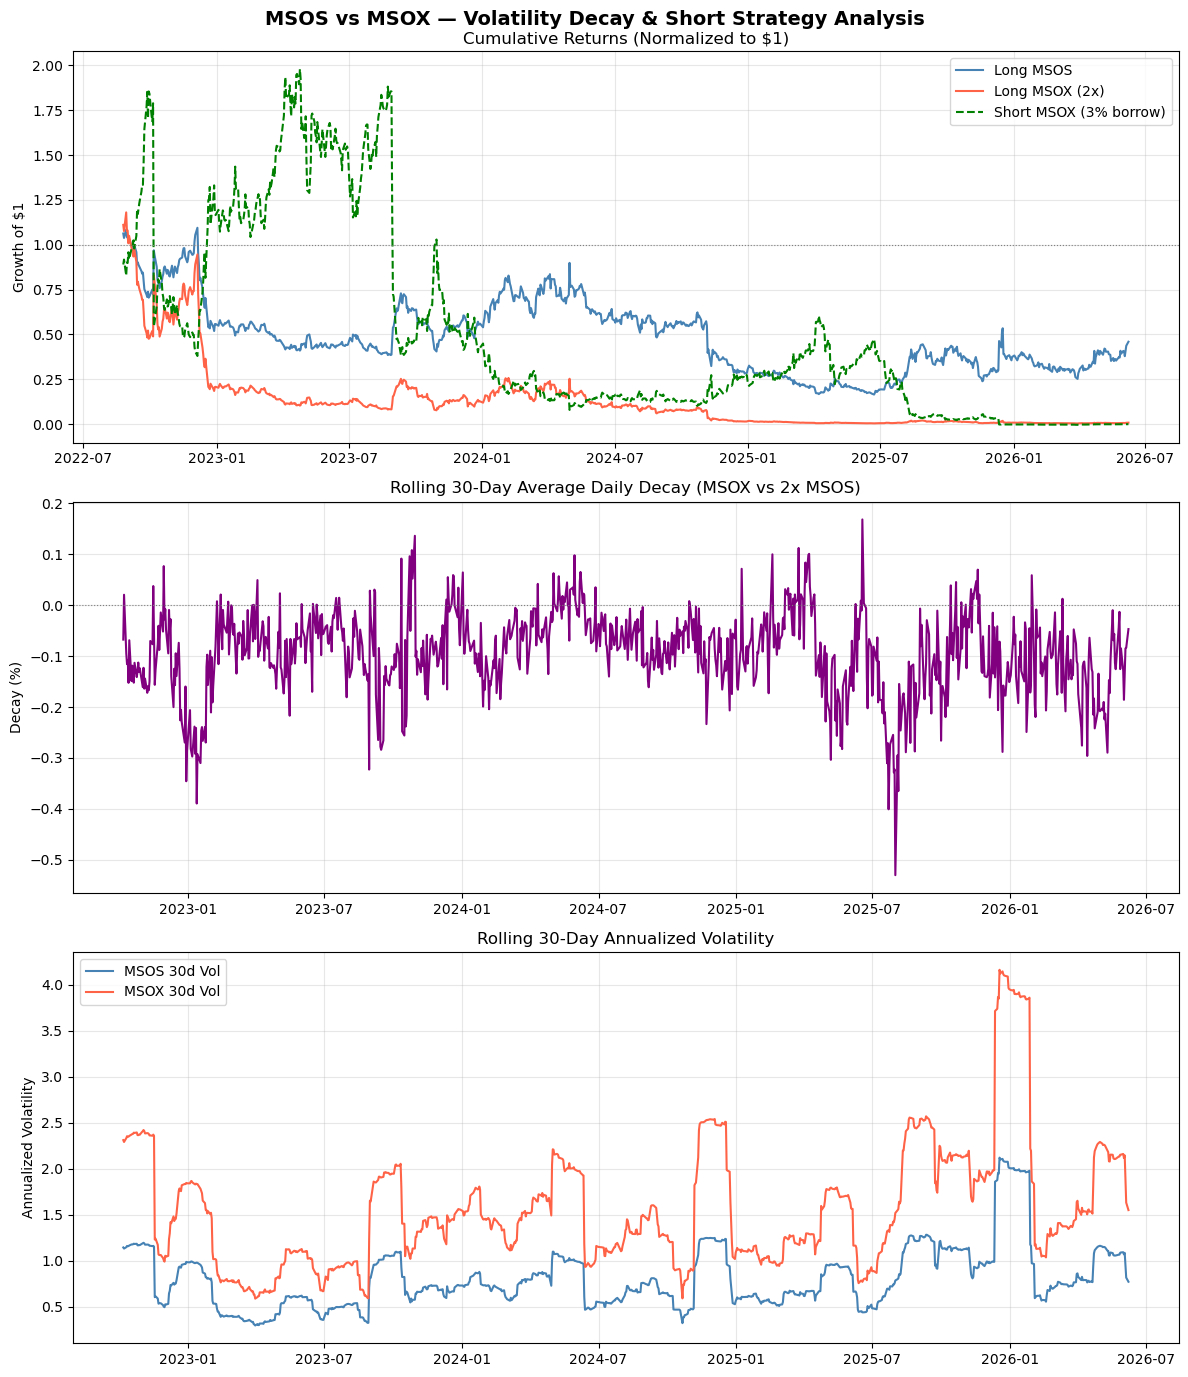


Chart saved → msos_msox_analysis_v2.png

=== Decay Summary Table ===
                      Metric    Value
      Mean Daily Return MSOS  0.0596%
      Mean Daily Return MSOX  0.0263%
Mean Expected 2x MSOS Return  0.1193%
            Mean Daily Decay -0.0930%
   Annualized Decay Estimate  -23.44%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────

file = "MSOS_MSOX.xlsx"

msos = pd.read_excel(file, sheet_name="MSOS")
msox = pd.read_excel(file, sheet_name="MSOX")

# ── 2. CLEAN & PARSE DATES ────────────────────────────────────────────────────

def clean_df(df, name):
    df = df.copy()
    df.columns = df.columns.str.strip()
    if pd.api.types.is_numeric_dtype(df["Date"]):
        df["Date"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["Date"], unit="D")
    else:
        df["Date"] = pd.to_datetime(df["Date"])
    df = df.rename(columns={"Last Price": name})
    df = df[["Date", name]].dropna()
    df = df.sort_values("Date").reset_index(drop=True)
    return df

msos = clean_df(msos, "MSOS")
msox = clean_df(msox, "MSOX")

# ── 3. MERGE ──────────────────────────────────────────────────────────────────

df = pd.merge(msos, msox, on="Date", how="inner")
print(f"Data range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total trading days: {len(df)}\n")

# ── 4. SIMPLE DAILY RETURNS (not log returns) ─────────────────────────────────

df["ret_MSOS"] = df["MSOS"].pct_change()
df["ret_MSOX"] = df["MSOX"].pct_change()
df = df.dropna().reset_index(drop=True)

# ── 5. VOLATILITY DECAY (SIMPLE RETURN METHOD) ────────────────────────────────

df["expected_2x_MSOS"] = 2 * df["ret_MSOS"]
df["daily_decay"]      = df["ret_MSOX"] - df["expected_2x_MSOS"]
ann_decay              = df["daily_decay"].mean() * 252
theoretical_decay      = -0.5 * (df["ret_MSOX"].std() ** 2) * 252

print("=== Volatility Decay (Simple Return Method) ===")
print(f"  Mean daily decay          : {df['daily_decay'].mean()*100:.4f}%")
print(f"  Annualized decay estimate : {ann_decay*100:.2f}%")
print(f"  Theoretical ½σ² estimate  : {theoretical_decay*100:.2f}%\n")

# ── 6. PERFORMANCE METRICS ────────────────────────────────────────────────────

def performance(returns, label):
    # Geometric CAGR
    n_years  = len(returns) / 252
    terminal = (1 + returns).prod()
    cagr     = terminal ** (1 / n_years) - 1

    ann_std  = returns.std() * np.sqrt(252)
    sharpe   = cagr / ann_std if ann_std != 0 else np.nan

    cum      = (1 + returns).cumprod()
    roll_max = cum.cummax()
    mdd      = ((cum - roll_max) / roll_max).min()

    sortino_denom = returns[returns < 0].std() * np.sqrt(252)
    sortino  = cagr / sortino_denom if sortino_denom != 0 else np.nan

    calmar   = cagr / abs(mdd) if mdd != 0 else np.nan

    print(f"--- {label} ---")
    print(f"  Terminal $1 → ${terminal:.4f}")
    print(f"  CAGR (geometric)  : {cagr*100:.1f}%")
    print(f"  Ann. Volatility   : {ann_std*100:.1f}%")
    print(f"  Sharpe            : {sharpe:.3f}")
    print(f"  Sortino           : {sortino:.3f}")
    print(f"  Calmar            : {calmar:.3f}")
    print(f"  Max Drawdown      : {mdd*100:.1f}%\n")
    return cagr, sharpe, mdd, terminal

print("=== Strategy Performance ===")
performance(df["ret_MSOS"],        "Long MSOS (Buy & Hold)")
performance(df["ret_MSOX"],        "Long MSOX (Buy & Hold)")
performance(-df["ret_MSOX"] - 0.03/252, "Short MSOX (3% Borrow Cost)")

# ── 7. ANNUAL DECAY BREAKDOWN ─────────────────────────────────────────────────

df["Year"] = df["Date"].dt.year
annual = df.groupby("Year").agg(
    decay    = ("daily_decay",  lambda x: x.mean() * 252 * 100),
    msos_vol = ("ret_MSOS",     lambda x: x.std() * np.sqrt(252) * 100),
    msox_vol = ("ret_MSOX",     lambda x: x.std() * np.sqrt(252) * 100),
    days     = ("ret_MSOS",     "count")
).reset_index()

print("=== Annual Decay & Volatility ===")
print(annual.to_string(index=False))

# ── 8. CUMULATIVE RETURNS ─────────────────────────────────────────────────────

df["cum_msos"]       = (1 + df["ret_MSOS"]).cumprod()
df["cum_msox"]       = (1 + df["ret_MSOX"]).cumprod()
df["cum_short_msox"] = (1 + (-df["ret_MSOX"] - 0.03/252)).cumprod()

# ── 9. ROLLING VOLATILITY ─────────────────────────────────────────────────────

df["vol_MSOS_30d"] = df["ret_MSOS"].rolling(30).std() * np.sqrt(252)
df["vol_MSOX_30d"] = df["ret_MSOX"].rolling(30).std() * np.sqrt(252)

# ── 10. PLOTS ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle("MSOS vs MSOX — Volatility Decay & Short Strategy Analysis", fontsize=14, fontweight="bold")

# Plot 1: Cumulative returns (normalized to $1)
axes[0].plot(df["Date"], df["cum_msos"],       label="Long MSOS",           color="steelblue")
axes[0].plot(df["Date"], df["cum_msox"],       label="Long MSOX (2x)",      color="tomato")
axes[0].plot(df["Date"], df["cum_short_msox"], label="Short MSOX (3% borrow)", color="green", linestyle="--")
axes[0].axhline(1, color="gray", linestyle=":", linewidth=0.8)
axes[0].set_title("Cumulative Returns (Normalized to $1)")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Daily decay over time
axes[1].plot(df["Date"], df["daily_decay"].rolling(30).mean() * 100, color="purple")
axes[1].axhline(0, color="gray", linestyle=":", linewidth=0.8)
axes[1].set_title("Rolling 30-Day Average Daily Decay (MSOX vs 2x MSOS)")
axes[1].set_ylabel("Decay (%)")
axes[1].grid(alpha=0.3)

# Plot 3: Rolling volatility
axes[2].plot(df["Date"], df["vol_MSOS_30d"], label="MSOS 30d Vol", color="steelblue")
axes[2].plot(df["Date"], df["vol_MSOX_30d"], label="MSOX 30d Vol", color="tomato")
axes[2].set_title("Rolling 30-Day Annualized Volatility")
axes[2].set_ylabel("Annualized Volatility")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("msos_msox_analysis_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved → msos_msox_analysis_v2.png")

# ── 11. DECAY SUMMARY TABLE ───────────────────────────────────────────────────

summary = pd.DataFrame({
    "Metric": [
        "Mean Daily Return MSOS",
        "Mean Daily Return MSOX",
        "Mean Expected 2x MSOS Return",
        "Mean Daily Decay",
        "Annualized Decay Estimate",
    ],
    "Value": [
        f"{df['ret_MSOS'].mean()*100:.4f}%",
        f"{df['ret_MSOX'].mean()*100:.4f}%",
        f"{df['expected_2x_MSOS'].mean()*100:.4f}%",
        f"{df['daily_decay'].mean()*100:.4f}%",
        f"{ann_decay*100:.2f}%",
    ]
})
print("\n=== Decay Summary Table ===")
print(summary.to_string(index=False))